# TI-v-fade paper board

Causal V-fade shadow on warehouse tape. **Not** MM · **not** live orders.

Scoreboard = lab identity `−mo_5s − 4` (matches Promote). Path PnL = entry@+2s → exit tape prints.


In [1]:
from pathlib import Path
import json
import pandas as pd

OUT = Path('out')
rollup = json.loads((OUT / 'rollup.json').read_text())
trades = [json.loads(l) for l in (OUT / 'trades.jsonl').read_text().splitlines() if l.strip()]
df = pd.DataFrame(trades)
lab = rollup['lab_pnl_net_bps']
path = rollup['path_pnl_net_bps']
kills = rollup['kills']
print(f"n_faded={rollup['n_faded']}  lab_mean={lab['mean']:.2f} CI[{lab['lo']:.2f},{lab['hi']:.2f}]")
print(f"path_mean={path['mean']:.2f} CI[{path['lo']:.2f},{path['hi']:.2f}]")
print(f"early={rollup['early_mean']:.2f} late={rollup['late_mean']:.2f} hit={rollup['hit_rate']:.3f}")
print(f"kill={kills['decision']} any_kill={kills['any_kill']}")
print('flags:', {k:v for k,v in kills['flags'].items() if v})
df[['day','event_i','side_name','exit_reason','lab_pnl_net_bps','path_pnl_net_bps','mo_5s']].head(20)


n_faded=63  lab_mean=13.90 CI[8.55,19.36]
path_mean=-7.17 CI[-9.75,-4.21]
early=9.80 late=15.95 hit=0.841
kill=Promote_shadow any_kill=0
flags: {}


,day,event_i,side_name,exit_reason,lab_pnl_net_bps,path_pnl_net_bps,mo_5s
0,2026-09-04,0,sell,time_stop,26.244984,4.083258,-30.244984
1,2026-09-04,3,buy,time_stop,8.647981,-2.989338,-12.647981
2,2026-09-04,4,sell,time_stop,21.697874,3.571933,-25.697874
3,2026-09-04,5,buy,time_stop,14.719012,-1.979696,-18.719012
4,2026-09-04,8,sell,adverse_stop,-3.487442,-27.089948,-0.512558
5,2026-09-04,9,sell,adverse_stop,3.170294,-25.042907,-7.170294
6,2026-09-04,10,sell,time_stop,-13.196342,-12.684990,9.196342
7,2026-09-04,11,buy,time_stop,10.811788,-2.979904,-14.811788
8,2026-09-04,12,buy,time_stop,10.914627,-4.000000,-14.914627
9,2026-09-04,13,buy,time_stop,-3.485861,-0.399918,-0.514139


In [2]:
# Per-day lab means + exit mix
by = df.groupby('day').agg(
    n=('lab_pnl_net_bps','size'),
    lab_mean=('lab_pnl_net_bps','mean'),
    path_mean=('path_pnl_net_bps','mean'),
    hit=('lab_pnl_net_bps', lambda s: (s>0).mean()),
    adverse=('exit_reason', lambda s: (s=='adverse_stop').mean()),
)
by.round(2)


,n,lab_mean,path_mean,hit,adverse
day,,,,,
2026-09-04,11,8.84,-6.68,0.73,0.18
2026-09-05,2,5.75,-11.43,0.50,0.50
2026-09-06,8,12.13,-4.69,1.00,0.00
2026-09-07,3,8.22,-8.04,0.67,0.33
2026-09-08,27,20.70,-6.85,0.96,0.33
2026-09-09,11,6.37,-9.50,0.64,0.18
2026-09-10,1,16.59,-4.00,1.00,0.00


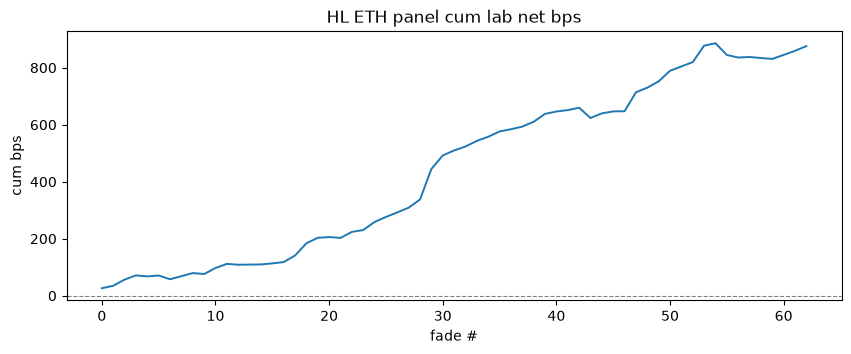

In [3]:
import matplotlib.pyplot as plt
eq = df['lab_pnl_net_bps'].cumsum()
fig, ax = plt.subplots(figsize=(10,3.5))
ax.plot(eq.values, lw=1.4)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_title('HL ETH panel cum lab net bps')
ax.set_xlabel('fade #'); ax.set_ylabel('cum bps')
plt.show()
